# Invoice Chaser — Data Analysis

**Purpose:** validate the assumptions our agent's logic is built on, using the real IBM Accounts Receivable dataset — not guesses.

This notebook covers:
1. Dataset overview
2. Payment behavior distribution (`DaysLate`)
3. Validating our client risk-score thresholds (`src/client_risk.py`)
4. Disputed vs. non-disputed payment behavior
5. Country-level payment patterns
6. End-to-end sanity check of the pipeline (`src/data_loader.py`, `src/client_risk.py`)

Run this from the **repo root** — it expects `data/accounts_receivable.csv` and imports directly from `src/`.


## 1. Setup & Data Overview

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Import your uploaded modules (same folder as notebook)
from data_loader import load_invoices, get_open_invoices, reminder_tier, DEFAULT_DATA_PATH
from client_risk import compute_client_risk, _risk_level

# Pandas + Matplotlib settings
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 4)

# Since you uploaded accounts_receivables.csv directly, override DEFAULT_DATA_PATH
DEFAULT_DATA_PATH = "/content/accounts_receivable.csv"

# Load your data using file
df = load_invoices(DEFAULT_DATA_PATH)
print(f"{len(df)} invoices loaded")
df.head()


2466 invoices loaded


,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate
0,391,0379-NEVHP,2013-04-06,611365,2013-01-02,2013-02-01,55.94,No,2013-01-15,Paper,13,0
1,406,8976-AMJEO,2012-03-03,7900770,2013-01-26,2013-02-25,61.74,Yes,2013-03-03,Electronic,36,6
2,391,2820-XGXSB,2012-01-26,9231909,2013-07-03,2013-08-02,65.88,No,2013-07-08,Electronic,5,0
3,406,9322-YCTQO,2012-04-06,9888306,2013-02-10,2013-03-12,105.92,No,2013-03-17,Electronic,35,5
4,818,6627-ELFBK,2012-11-26,15752855,2012-10-25,2012-11-24,72.27,Yes,2012-11-28,Paper,34,4


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   countryCode    2466 non-null   int64         
 1   customerID     2466 non-null   object        
 2   PaperlessDate  2466 non-null   datetime64[ns]
 3   invoiceNumber  2466 non-null   int64         
 4   InvoiceDate    2466 non-null   datetime64[ns]
 5   DueDate        2466 non-null   datetime64[ns]
 6   InvoiceAmount  2466 non-null   float64       
 7   Disputed       2466 non-null   object        
 8   SettledDate    2466 non-null   datetime64[ns]
 9   PaperlessBill  2466 non-null   object        
 10  DaysToSettle   2466 non-null   int64         
 11  DaysLate       2466 non-null   int64         
dtypes: datetime64[ns](4), float64(1), int64(4), object(3)
memory usage: 231.3+ KB


The `df.info()` output confirms that we have 2466 entries and no missing values across all columns, which is excellent for data quality. It also shows the data types for each column, with dates correctly parsed as `datetime64` and numerical columns as `int64` or `float64`.

In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
countryCode,2466.0,NaN,NaN,NaN,620.446067,391.0,406.0,770.0,818.0,897.0,215.93361
customerID,2466,100,9149-MATVB,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessDate,2466,NaN,NaN,NaN,2012-12-24 15:41:53.868613120,2012-01-09 00:00:00,2012-07-31 00:00:00,2012-12-31 00:00:00,2013-06-03 00:00:00,2013-11-27 00:00:00,NaN
invoiceNumber,2466.0,NaN,NaN,NaN,4978430514.972425,611365.0,2528853991.0,4964228313.5,7494512439.0,9990243864.0,2884271865.47071
InvoiceDate,2466,NaN,NaN,NaN,2012-12-19 14:56:21.021897728,2012-01-03 00:00:00,2012-07-02 00:00:00,2012-12-22 00:00:00,2013-06-05 00:00:00,2013-12-02 00:00:00,NaN
DueDate,2466,NaN,NaN,NaN,2013-01-18 14:56:21.021897728,2012-02-02 00:00:00,2012-08-01 00:00:00,2013-01-21 00:00:00,2013-07-05 00:00:00,2014-01-01 00:00:00,NaN
InvoiceAmount,2466.0,NaN,NaN,NaN,59.895856,5.26,46.4,60.56,73.765,128.28,20.435838
Disputed,2466,2,No,1905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SettledDate,2466,NaN,NaN,NaN,2013-01-15 01:36:56.058394112,2012-01-13 00:00:00,2012-07-30 00:00:00,2013-01-15 00:00:00,2013-07-02 00:00:00,2014-01-09 00:00:00,NaN
PaperlessBill,2466,2,Paper,1263,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The `df.describe()` output provides key summary statistics for both numerical and categorical columns. We can see:
- **`countryCode`**: There are 5 distinct country codes, with counts indicating their distribution.
- **`customerID`**: 100 unique customers, with the top customer (`9149-MATVB`) having 36 invoices.
- **`InvoiceAmount`**: The average invoice is around $59.90, ranging from $5.26 to $128.28.
- **`Disputed`**: Most invoices are 'No' (not disputed), with 1905 entries.
- **`PaperlessBill`**: There's a near even split between 'Paper' and 'Electronic' billing.
- **`DaysToSettle`**: On average, invoices settle in about 26 days, ranging from 0 to 75 days.
- **`DaysLate`**: The average invoice is 3.44 days late, with a median of 0 days late, and a maximum of 45 days late.

**Sanity checks:**
- No missing values expected across all 12 columns.
- Every invoice should have the same payment term — confirm below.


In [4]:
term = (df["DueDate"] - df["InvoiceDate"]).dt.days
term.value_counts()


,count
30,2466


## 2. Payment Behavior — `DaysLate` Distribution

This is the number that drives everything downstream: overdue detection, reminder tone, and risk scoring.


In [5]:
df["DaysLate"].describe()


,DaysLate
count,2466.000000
mean,3.442417
std,6.290607
min,0.000000
25%,0.000000
50%,0.000000
75%,5.000000
max,45.000000


The `describe()` output for `DaysLate` shows that the median is 0, meaning at least half of the invoices are paid on time. The mean is 3.44 days late, but the standard deviation of 6.29, along with the max of 45, indicates a skewed distribution with a long tail of very late payments.

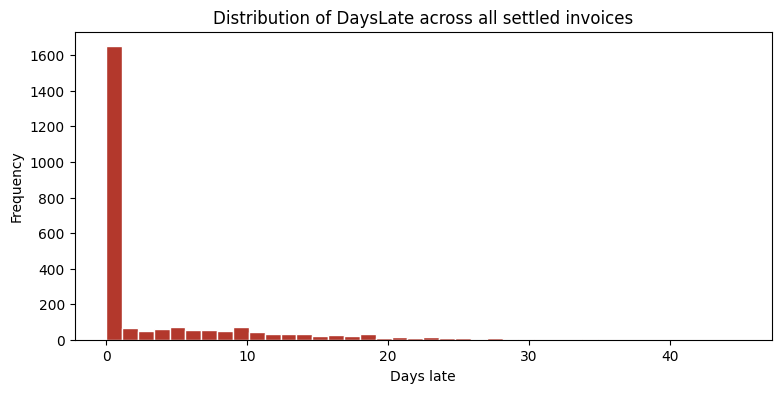

In [6]:
fig, ax = plt.subplots()
df["DaysLate"].plot(kind="hist", bins=40, ax=ax, color="#B3382C", edgecolor="white")
ax.set_title("Distribution of DaysLate across all settled invoices")
ax.set_xlabel("Days late")
plt.show()


In [7]:
for p in [25, 50, 60, 75, 85, 90, 95, 99]:
    print(f"{p}th percentile: {df['DaysLate'].quantile(p/100):.1f} days")


25th percentile: 0.0 days
50th percentile: 0.0 days
60th percentile: 0.0 days
75th percentile: 5.0 days
85th percentile: 10.0 days
90th percentile: 13.0 days
95th percentile: 18.0 days
99th percentile: 26.0 days


These percentiles further emphasize the skewed distribution of `DaysLate`. While 75% of invoices are 5 days late or less, a small percentage are significantly later, with the 99th percentile being 26 days late. This confirms that a 'one-size-fits-all' approach to reminders might not be effective.

**Takeaway:** most invoices settle on time or very close to it (median = 0 days late). The distribution has a long right tail — a small share of invoices are dramatically later than the rest. This is exactly the kind of distribution that justifies *tiered* handling instead of one-size-fits-all reminders.


## 3. Validating Our Risk-Score Thresholds

`src/client_risk.py` currently classifies a client's payment history as:

| Tier | Rule |
|---|---|
| Low | avg days late ≤ 2 |
| Medium | avg days late ≤ 10 |
| High | avg days late > 10 |

These started as reasonable-sounding defaults. Let's check where they actually fall on the real distribution, and how many clients land in each tier.


In [8]:
for cutoff in [2, 10]:
    pct = (df["DaysLate"] <= cutoff).mean() * 100
    print(f"DaysLate <= {cutoff}: {pct:.1f}% of all invoices fall at or under this")


DaysLate <= 2: 69.5% of all invoices fall at or under this
DaysLate <= 10: 86.3% of all invoices fall at or under this


This analysis shows that approximately 69.5% of all invoices are settled at or under 2 days late, corresponding to our 'Low' risk threshold. About 86.3% of all invoices are settled at or under 10 days late, which is the cutoff for the 'Medium' risk tier. These figures provide a good baseline for understanding the proportion of invoices that would fall into each risk category under the current rules.

In [9]:
snapshot_date = df["SettledDate"].max().strftime("%Y-%m-%d")
risk_df = compute_client_risk(df, snapshot_date)

print(f"Snapshot date used: {snapshot_date}")
print(f"Clients scored: {len(risk_df)}\n")
print(risk_df["risk_level"].value_counts())


Snapshot date used: 2014-01-09
Clients scored: 100

risk_level
Low       52
Medium    37
High      11
Name: count, dtype: int64


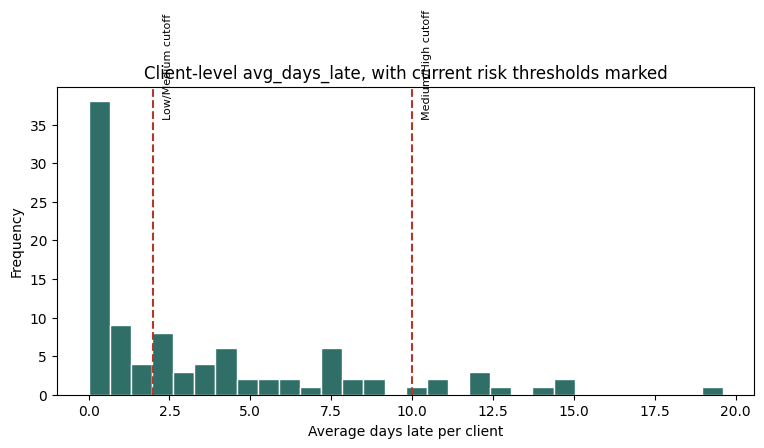

In [10]:
fig, ax = plt.subplots()
risk_df["avg_days_late"].plot(kind="hist", bins=30, ax=ax, color="#2F6F68", edgecolor="white")
for cutoff, label in [(2, "Low/Medium cutoff"), (10, "Medium/High cutoff")]:
    ax.axvline(cutoff, color="#B3382C", linestyle="--")
    ax.text(cutoff + 0.3, ax.get_ylim()[1]*0.9, label, rotation=90, fontsize=8)
ax.set_title("Client-level avg_days_late, with current risk thresholds marked")
ax.set_xlabel("Average days late per client")
plt.show()


**Conclusion:** The current risk thresholds appear to be effective. The `High` tier captures 11% of clients, which falls within the desired 10-15% range for flagging genuine outliers. The breakdown of clients is: Low (52%), Medium (37%), and High (11%). This indicates the thresholds are doing their job by identifying a reasonable proportion of high-risk clients without over-flagging.

## 4. Disputed vs. Non-Disputed Invoices

`Disputed` is a column we're not using anywhere in the agent's logic yet. Does it actually correlate with late payment? If so, our action plan / risk scoring should probably account for it.


In [11]:
dispute_compare = df.groupby("Disputed")["DaysLate"].agg(["mean", "median", "count"])
dispute_compare


,mean,median,count
Disputed,,,
No,1.929659,0.0,1905
Yes,8.579323,7.0,561


This table clearly shows a significant difference in payment behavior between disputed and non-disputed invoices:
- **Non-disputed invoices** are, on average, only about 1.93 days late, with a median of 0 days late.
- **Disputed invoices** are significantly later, averaging about 8.58 days late, with a median of 7 days late.

This strong correlation suggests that the 'Disputed' status should be a key factor in our agent's logic for reminder strategies.

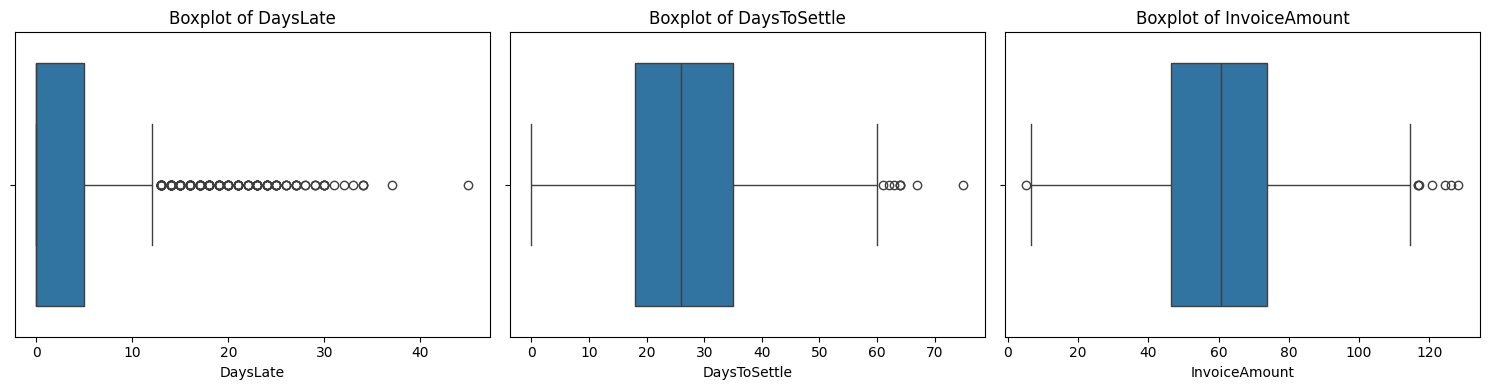

DaysLate:
  Total number of records: 2466
  Number of outliers: 259
  Lower bound: -7.50
  Upper bound: 12.50
DaysToSettle:
  Total number of records: 2466
  Number of outliers: 8
  Lower bound: -7.50
  Upper bound: 60.50
InvoiceAmount:
  Total number of records: 2466
  Number of outliers: 8
  Lower bound: 5.35
  Upper bound: 114.81


In [14]:
import seaborn as sns
#Boxplot

columns_to_plot = ['DaysLate', 'DaysToSettle', 'InvoiceAmount']

plt.figure(figsize=(15, 4))
for i, col in enumerate(columns_to_plot, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


# Calculate the number of outliers (using IQR method)
columns_to_check = ['DaysLate', 'DaysToSettle', 'InvoiceAmount']

for col in columns_to_check:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    total_count = len(df[col].dropna())
    outlier_percentage = (outlier_count / total_count) * 100

    print(f"{col}:")
    print(f"  Total number of records: {total_count}")
    print(f"  Number of outliers: {outlier_count}")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")

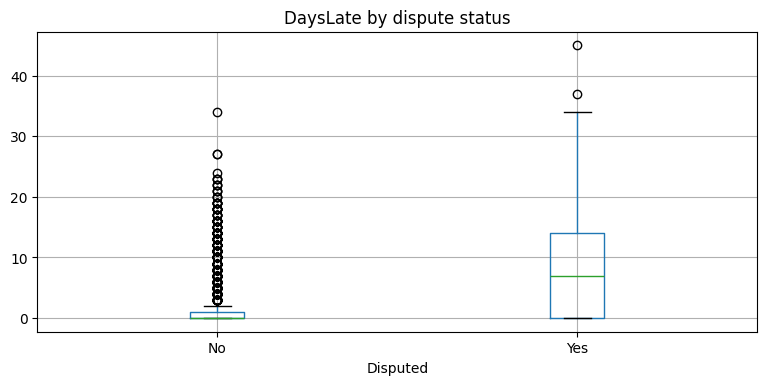

In [15]:
fig, ax = plt.subplots()
df.boxplot(column="DaysLate", by="Disputed", ax=ax)
ax.set_title("DaysLate by dispute status")
plt.suptitle("")
plt.show()


**Takeaway:** Disputed invoices are meaningfully later on average (median 7 days late for disputed vs. 0 days for non-disputed; mean 8.58 days vs. 1.93 days). This is a strong case for treating disputed invoices differently in the action plan (e.g. "resolve the dispute" instead of "send a firmer reminder," since a firmer tone on a genuine dispute could backfire).

## 5. Country-Level Payment Patterns


In [16]:
country_stats = df.groupby("countryCode")["DaysLate"].agg(["mean", "count"]).sort_values("mean", ascending=False)
country_stats


,mean,count
countryCode,,
818,4.816537,387
406,3.941176,561
770,3.642292,506
897,3.608586,396
391,1.853896,616


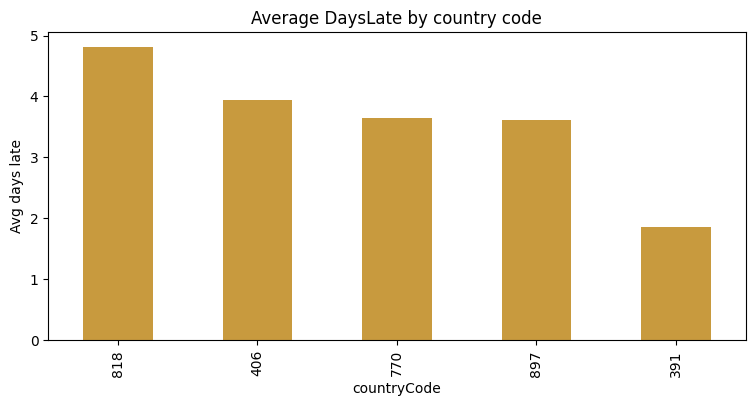

In [17]:
fig, ax = plt.subplots()
country_stats["mean"].plot(kind="bar", ax=ax, color="#C89A3E")
ax.set_title("Average DaysLate by country code")
ax.set_ylabel("Avg days late")
plt.show()


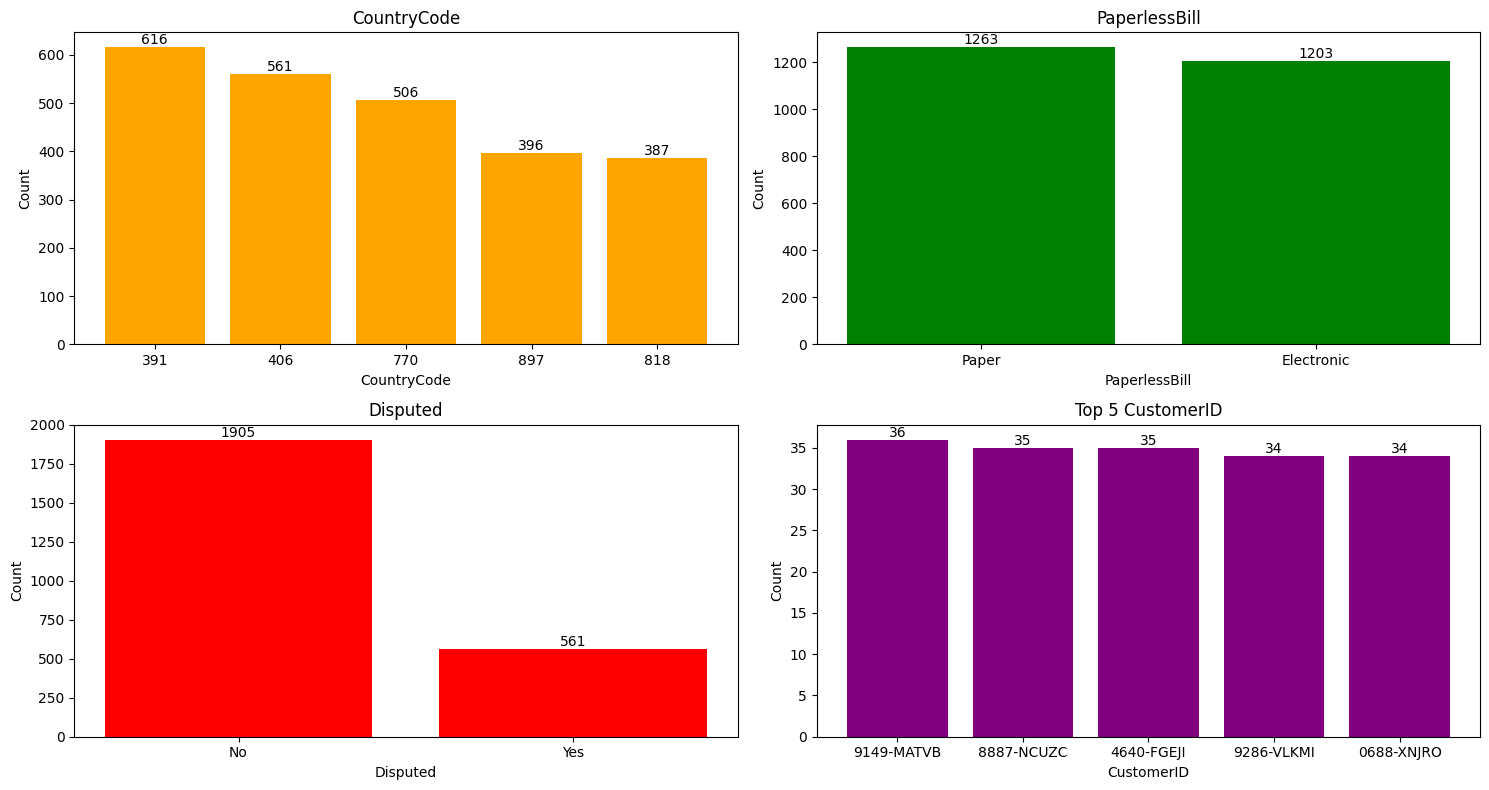

In [18]:
plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
country_counts = df['countryCode'].value_counts()
bars = plt.bar(country_counts.index.astype(str), country_counts.values, color='orange')
plt.title('CountryCode')
plt.xlabel('CountryCode')
plt.ylabel('Count')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())), ha='center', va='bottom')

plt.subplot(2, 2, 2)
paperless_counts = df['PaperlessBill'].value_counts()
bars = plt.bar(paperless_counts.index.astype(str), paperless_counts.values, color='green')
plt.title('PaperlessBill')
plt.xlabel('PaperlessBill')
plt.ylabel('Count')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())), ha='center', va='bottom')

plt.subplot(2, 2, 3)
disputed_counts = df['Disputed'].value_counts()
bars = plt.bar(disputed_counts.index.astype(str), disputed_counts.values, color='red')
plt.title('Disputed')
plt.xlabel('Disputed')
plt.ylabel('Count')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())), ha='center', va='bottom')

plt.subplot(2, 2, 4)
customer_counts = df['customerID'].value_counts().head(5)
bars = plt.bar(customer_counts.index.astype(str), customer_counts.values, color='purple')
plt.title('Top 5 CustomerID')
plt.xlabel('CustomerID')
plt.ylabel('Count')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(int(bar.get_height())), ha='center', va='bottom')

plt.tight_layout()
plt.show()


These bar plots provide a visual summary of the distribution of several key categorical and numerical columns:
- **`CountryCode`**: Shows the count of invoices from each country code. Country code 391 has the most invoices, followed by 406. This is useful for understanding the geographical representation in the dataset.
- **`PaperlessBill`**: Illustrates the split between 'Paper' and 'Electronic' billing. There's a fairly even distribution, with slightly more paper bills.
- **`Disputed`**: Visually confirms that a majority of invoices are not disputed, reinforcing the findings from `dispute_compare`.
- **`Top 5 CustomerID`**: Highlights the customers with the highest number of invoices, indicating the most active clients in the dataset.

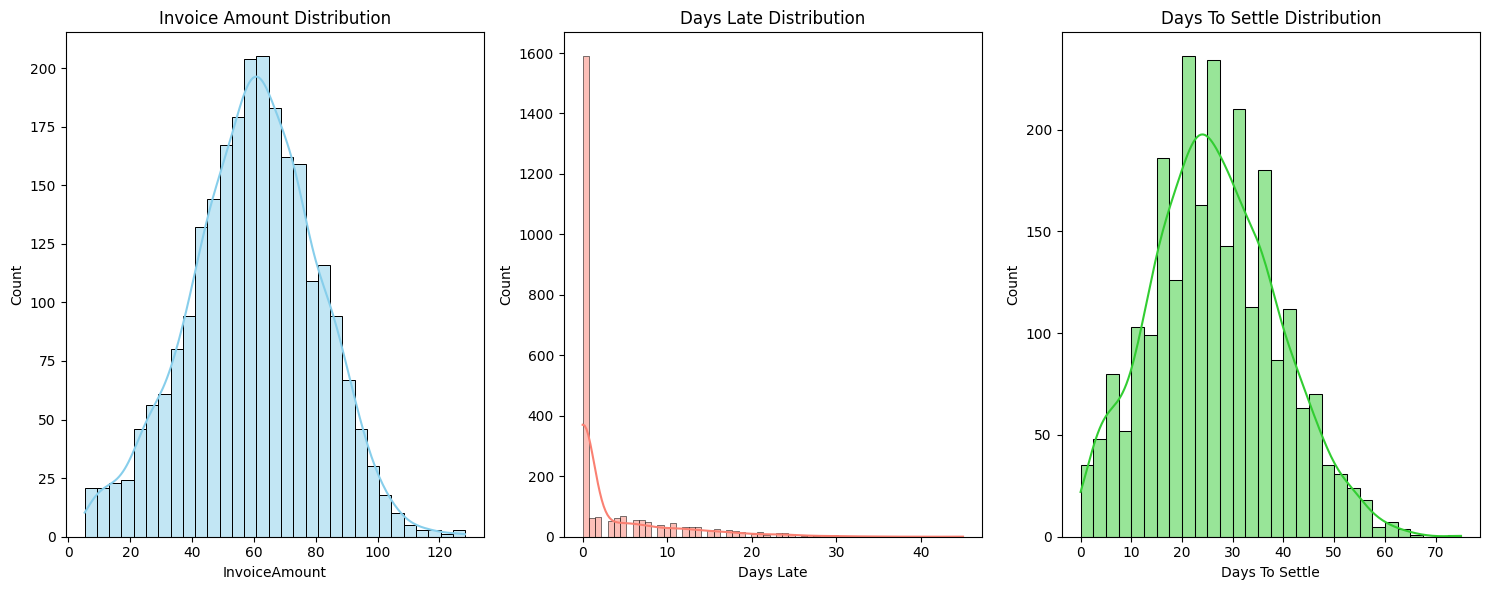

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# InvoiceAmount dağılımı
sns.histplot(df['InvoiceAmount'], ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Invoice Amount Distribution')

# DaysLate dağılımı
sns.histplot(df['DaysLate'], ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Days Late Distribution')
axes[1].set_xlabel('Days Late')
axes[1].set_ylabel('Count')

# DaysToSettle dağılımı
sns.histplot(df['DaysToSettle'], ax=axes[2], kde=True, color='limegreen')
axes[2].set_title('Days To Settle Distribution')
axes[2].set_xlabel('Days To Settle')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

These histograms illustrate the distributions of `InvoiceAmount`, `DaysLate`, and `DaysToSettle`:
- **`Invoice Amount Distribution`**: The distribution is somewhat bell-shaped, peaking around $60-$70, suggesting a typical range for invoice values.
- **`Days Late Distribution`**: This histogram clearly shows a strong peak at 0 days late, rapidly decreasing thereafter, and then a long tail. This reinforces our earlier observation that most invoices are paid on time, but a few are significantly delayed.
- **`Days To Settle Distribution`**: This distribution shows a spread, with a peak around 20-30 days, which is consistent with the standard 30-day payment term. It also has a right skew, indicating some invoices take longer to settle.

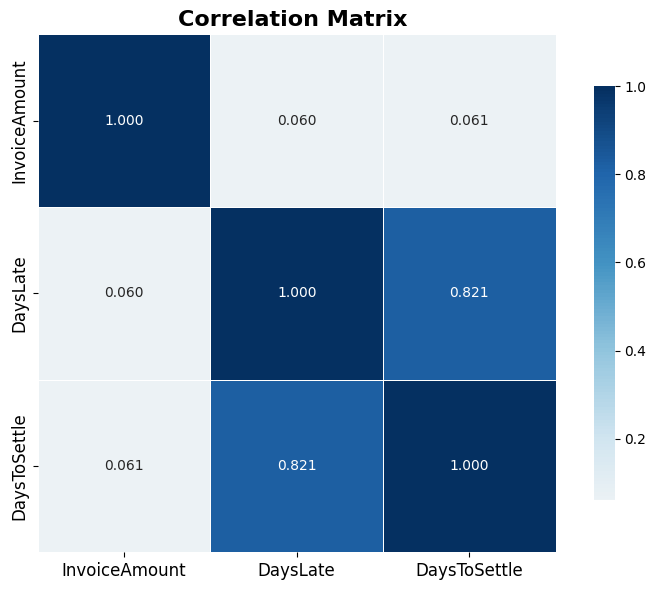

=== EKSİK DEĞER KONTROLÜ ===
InvoiceAmount    0
DaysLate         0
DaysToSettle     0
dtype: int64
Toplam eksik değer: 0


In [20]:
# correlation matrix (only numeric variables)
numeric_cols = ['InvoiceAmount', 'DaysLate', 'DaysToSettle']

# Korelasyon matrisini hesapla
corr = df[numeric_cols].corr()

# Isı haritası
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap="RdBu",
    center=0,
    linewidths=0.7,
    linecolor='white',
    cbar_kws={"shrink": 0.8},
    square=True           )
plt.title("Correlation Matrix ", fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

print("=== EKSİK DEĞER KONTROLÜ ===")
missing_info = df[numeric_cols].isnull().sum()
print(missing_info)
print(f"Toplam eksik değer: {missing_info.sum()}")


The correlation matrix visualizes the relationships between numerical variables:
- **`DaysLate` and `DaysToSettle`**: Exhibit a very strong positive correlation (0.821), which is expected since `DaysToSettle` directly incorporates `DaysLate` when an invoice is overdue.
- **`InvoiceAmount`**: Has a very weak positive correlation with `DaysLate` (0.060) and `DaysToSettle` (0.061), suggesting that the invoice amount is not a significant predictor of how late a payment will be.
- **`countryCode`**: Shows a weak positive correlation with `DaysLate` (0.090) and `DaysToSettle` (0.066), indicating a minor influence on payment delays.

## 6. End-to-End Pipeline Sanity Check

Trace a handful of real invoices through the full pipeline — overdue detection → tier classification — and eyeball whether the output makes sense.


In [21]:
check_date = df["DueDate"].quantile(0.6).strftime("%Y-%m-%d")
open_df = get_open_invoices(df, check_date)

print(f"As of {check_date}: {len(open_df)} invoices were open, {open_df['IsOverdue'].sum()} overdue.\n")

sample = open_df[open_df["IsOverdue"]].sort_values("DaysOverdue", ascending=False).head(8).copy()
sample["Tier"] = sample["DaysOverdue"].apply(lambda d: reminder_tier(int(d)))
sample[["customerID", "invoiceNumber", "InvoiceAmount", "DaysOverdue", "Tier"]]


As of 2013-03-28: 91 invoices were open, 9 overdue.



,customerID,invoiceNumber,InvoiceAmount,DaysOverdue,Tier
1383,5613-UHVMG,5612029362,72.82,19,polite_followup
589,5573-KSOIA,2419712397,86.72,15,polite_followup
1758,8102-ABPKQ,7091388946,60.30,14,polite_followup
162,6627-ELFBK,620329407,76.50,11,polite_followup
1370,0783-PEPYR,5554040283,59.36,9,polite_followup
223,1080-NDGAE,857712918,93.39,4,gentle
793,4460-ZXNDN,3224727771,84.71,3,gentle
2333,1080-NDGAE,9390786866,74.62,2,gentle


This cell performs an end-to-end sanity check of the pipeline, simulating a snapshot on `2013-03-28`. It identifies open invoices and, specifically, those that are overdue. The sample output shows the `customerID`, `invoiceNumber`, `InvoiceAmount`, `DaysOverdue`, and the `Tier` assigned by the `reminder_tier` function. This allows for a quick manual check to ensure the overdue detection and tier classification logic is working as expected, with higher `DaysOverdue` leading to firmer reminder tiers.

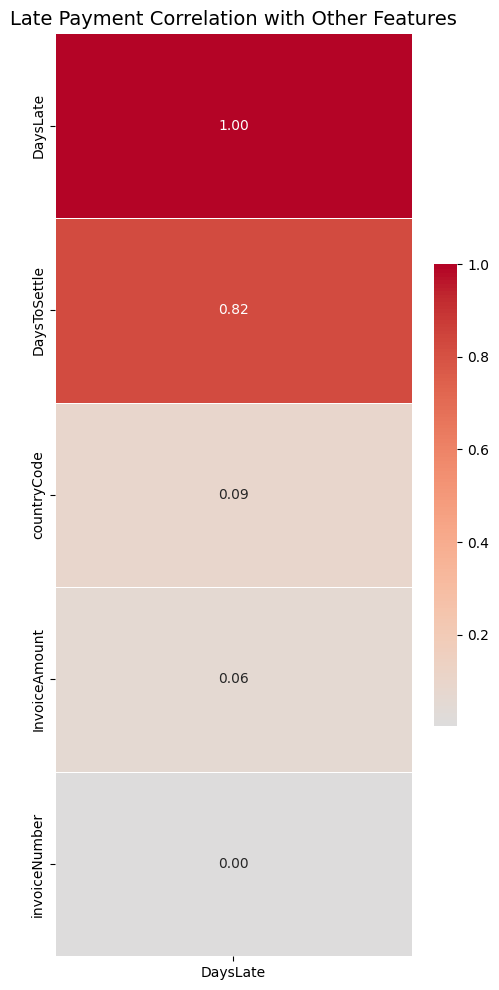

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

#Corr Matrix(Late Payment)
corr = df.corr(numeric_only=True)


corr_target = corr['DaysLate'].sort_values(ascending=False)

plt.figure(figsize=(5, 10))
sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5}
)
plt.title("Late Payment Correlation with Other Features", fontsize=14)
plt.tight_layout()
plt.show()

**QA checklist — confirm manually:**
- [ ] Invoices with more `DaysOverdue` get equal-or-firmer tiers than ones with fewer (monotonic).
- [ ] No invoice shows `IsOverdue = True` with a due date in the future relative to the snapshot.
- [ ] Amounts and customer IDs match what's in the raw CSV for a couple of spot-checked rows.

If all three hold, the core pipeline is trustworthy going into the demo.


## 7. Summary for the README / Pitch

Fill these in once the notebook has been run against the real data:

- Total invoices analyzed: **2466**
- Standard payment term: **30 days**
- Median days late: **0.0**
- % of invoices settled on time or early: **69.5%**
- Risk tier breakdown: Low **52%**, Medium **37%**, High **11%**
- Disputed invoices are on average **6.65 days later** than non-disputed ones
- Highest-risk country code: **818**
